In [210]:
class GraphSignal: 
    def __init__(self,V,W,f):
        self.f=np.array(f) 
        self.V=V 
        self.W=np.array(W)
        self.n=len(self.f)
        self.degree=np.sum(np.array(self.W),0)
        self.initdist=self.degree/np.sum(self.degree) 
        
class HeavySnowTransform:  
    def __init__(self,graphsignal):
        self.n=graphsignal.n
        self.f=graphsignal.f
        self.V=graphsignal.V
        self.nodeindex=np.arange(0,self.n,dtype='int')
        self.graphweight=graphsignal.W
        self.initdist=graphsignal.initdist
        self._initialize()
    
    def _initialize(self):
        self.tau=0
        self.b=0
        self.trajectory=[np.random.choice(self.n,1,p=self.initdist).item()]
        self.flowcount=[0]
        self.snowygrounds=None 
        self.eucliddistance=(np.array(self.f)[:,np.newaxis]-np.array(self.f)[np.newaxis,:])**2
        self.snowdistance=np.zeros((self.n,self.n))
        self.euclidweight=np.zeros((self.n,self.n))
        self.snowweight=np.zeros((self.n,self.n))
        
    def _snowonce(self,ell,maxflow):
        b=self.b        
        flowcount=self.flowcount[-1] 
        snowyground=self.snowygrounds[...,ell-1]
        currentnode=self.trajectory[-1] 
        neighbor=self.nodeindex[(self.graphweight>0)[currentnode]]
        transitionprob=None
        nextnode=None 
        downstream=None
        
        if flowcount >= maxflow: # reset 
            nextnode=np.random.choice(self.n,1,p=self.initdist).item()
            snowyground[nextnode]=snowyground[nextnode]+b
            flowcount=0
        elif sum(neighbor)==0: # empty neighborhood 
            nextnode=np.random.choice(self.n,1,p=self.initdist).item()
            snowyground[nextnode]=snowyground[nextnode]+b
            flowcount=0
        else:
            _transitionprob=self.graphweight[currentnode]/sum(self.graphweight[currentnode])
            nextnode=np.random.choice(self.n,1,p=_transitionprob).item()
            downstream=neighbor[np.where(snowyground[currentnode]>=snowyground[neighbor])]
            if nextnode in set(downstream): # flow 
                snowyground[nextnode]=snowyground[nextnode]+b
                flowcount=flowcount+1
            else: # block 
                nextnode=np.random.choice(self.n,1,p=self.initdist).item()
                snowyground[currentnode]=snowyground[currentnode]+b
                flowcount=0
        self.snowygrounds[...,ell]=snowyground
        self.flowcount=self.flowcount+[flowcount]
        self.trajectory=self.trajectory+[nextnode]
        
    def _getdegreematrix(self,matrix):
        return np.diag(np.sum(matrix,1))
    
    def _normalize(self,matrix): 
        return np.sqrt(self._getdegreematrix(matrix))@matrix@np.sqrt(self._getdegreematrix(matrix))
    
    def _updateeuclidweight(self):
        self.euclidweight=np.exp(-self.eucliddistance/(self.b**2))-np.eye(self.n)
        
    def _updatesnowdistance(self):
        self.snowdistance=np.sum((self.snowygrounds[:,np.newaxis,:]-self.snowygrounds[np.newaxis,:,:])**2,axis=-1)
             
    def _updatesnowweight(self):
        self.snowweight=np.exp(-self.snowdistance/(self.tau*self.b**2))-np.eye(self.n)
    
    def snow(self,tau,b=1,maxflow=99999):
        self._initialize()
        self.b=b
        self.tau=tau
        self.snowygrounds=np.repeat(self.f,self.tau+1).reshape(self.n,self.tau+1)
        print('HST (tau= %s, b=%s)' % (self.tau,self.b))
        for ell in np.arange(1,self.tau+1,dtype='int'): 
            print('\r'+str(ell)+'/'+str(self.tau),sep='',end='')
            self._snowonce(ell,maxflow)
        print('\n'+'HST completed and all history is recorded.')
        self._updatesnowdistance()
        self._updatesnowweight()
        self._updateeuclidweight()                

In [211]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA 
import rpy2 
%load_ext rpy2.ipython
%run pybase

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [212]:
### Example 2
np.random.seed(777)
import math
pi=math.pi
n=60
ang=np.linspace(-pi,pi-2*pi/n,n)
V=np.arange(n)+1
r=1
vx=r*np.cos(ang)
vy=r*np.sin(ang)
f1=vx*0

f2=vx*0
f2[vy<0]=3
f2[vy>=0]= -3

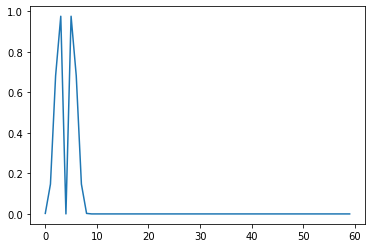

In [213]:
# Edg setting
Σ=l2distance(np.matrix([vx,vy]).T)
θ=0.05
W=np.exp(-Σ**2/(2*θ**2))-np.eye(n,n)
E=W>0
plt.plot(W[4,:].T)
# color
import matplotlib.cm as cm
col=list(np.array(cm.rainbow((ang+pi)/2/pi)))

In [214]:
gs1=GraphSignal(V,W,f1)
gs2=GraphSignal(V,W,f2)

In [215]:
hs1=HeavySnowTransform(gs1)
hs2=HeavySnowTransform(gs2)

In [219]:
hs2.snow(b=0.1,tau=50000)

HST (tau= 50000, b=0.1)
50000/50000
HST completed and all history is recorded.


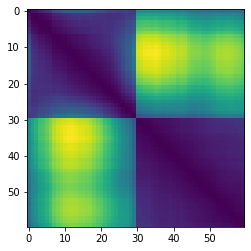

In [223]:
plt.imshow(hs2.snowdistance)